## **Identificación y clasificación de las etapas del sueño mediante dispositivos wearables**

#### **Autores:**
####  - Dennys Xavier Landy Rivera
####  - Sergio Moragón Jiménez

## **Resumen**
El análisis de la calidad del sueño es un factor fundamental de cara a la identificación de patologías relacionadas con el descanso, como puedan ser los distintos tipos de apnea o insomnio. Algo similar ocurre con afecciones ligadas a problemas de atención, cansancio perpetuo o inconveniencias pulmonares y cardíacas, que pueden suponer síntomas de enfermedades como esclerosis múltiple, determinados tipos de cáncer (como el de pulmón) o Parkinson, entre otras muchas.  
Este proyecto parte con la idea de identificar, a partir de información principalmente basada en los latidos del corazón, en qué etapa del sueño se encuentra una persona en cualquier momento de la noche, distinguiendo entre 4 posibles estados. \1*   El sujeto se encuentra despierto.
*   Fase de sueño ligero.
*   Sueño profundo
*   Fase REM (Rapid-Eye Movement)

Esto permite llevar a cabo ideas como realizar un estudio posterior de la calidad del sueño o añadir dispositivos de ruido blanco inteligentes, que, en función de la etapa  en la que se encuentren, emita a una frecuencia u otra (o deje de emitir).  
El presente trabajo toma como base el paper [_"Automated Multi-Stage Sleep Classification Using Wrist-Worn Photoplethysmography Signal "_](https://ieeexplore.ieee.org/abstract/document/11429301), publicado por Ragib Rowshon y Mohammod Abdul Motin en la _Convención de ingeniería en telecomunicaciones, electricidad y computación_ del IEEE, llevada a cabo en enero de 2026. Además de replicarlo, este proyecto tratará de ampliar sus capacidades por medio tanto de la adición de nuevos modelos de clasificación como de nuevas técnicas de explicabilidad, permitiendo un estudio mucho más rico de las decisiones del modelo de cara a detectar posibles sesgos o artefactos estadísticos en el aprendizaje.

## **Introducción**
Tomando como eje central del problema el estudio de la calidad del sueño, este trabajo también persigue otro objetivo.  
El análisis del sueño, como ya se ha comentado, resulta de vital importancia para la identificación de determinadas patologías. Sin embargo, el principal inconveniente reside en los dispositivos necesarios para llevarlas a cabo, que a menudo, consisten en un cableado similar al empleado para la realización de electrocardiogramas y encefalogramas. Dejando a un lado el elevado coste que puede suponer, estos dispositivos tan aparatosos pueden resultar realmente incómodos, complicando el estudio al dificultar la conciliación del sueño, las posturas naturales a la hora de dormir y, en general, haciendo que este análisis no sea sostenible a lo largo del tiempo (además de la evidente afección sobre los datos recogidos que pueden darse).  
Por ello, la idea es utilizar informaciín recogida por dispositivos "_wearables_", como pulseras o anillos inteligentes, que permiten una monitorización mucho menos invasiva. Estos se basan en la emisión de luz contra la piel, ya que, en función del estado de sueño en el que se encuentre una persona, la absorbancia de la piel ante las partículas de luz se comporta de forma distinta. Esto permite extraer información realmente precisa acerca de características como la frecuencia cardíaca o el nivel de oxígeno en sangre; del que se pueden derivar otras como el estrés o la frecuencia respiratoria (esta última, clave de cara a la identificación de apneas). Este informe se denomina _"Fotopletismografía"_.
En definitiva, la idea principal es llevar a cabo el estudio mencionado con la mayor precisión y el menor impacto sobre la calidad de sueño del paciente, sentando las bases para realizar estudios más detallados de patologías individuales.


In [56]:
# ============================================================
# Configuración y preparación de datos
# Ejecutar en orden para reproducir todos los resultados
# ============================================================

import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

RUTA_PROYECTO = os.getcwd()
sys.path.insert(0, RUTA_PROYECTO)

#print(f"Ruta del proyecto: {RUTA_PROYECTO}")

# Si X_features.csv no existe, ejecutamos la extracción automáticamente
ruta_features = os.path.join(RUTA_PROYECTO, 'data', 'processed', 'X_features.csv')

if not os.path.exists(ruta_features):
    print("\nGenerando features del dataset — esto puede tardar ~15 minutos...")
    import yaml
    from main import cargar_config, extraer_caracteristicas_dataset
    with open(os.path.join(RUTA_PROYECTO, 'configs', 'config.yaml')) as f:
        cfg = yaml.safe_load(f)
    extraer_caracteristicas_dataset(cfg, RUTA_PROYECTO)
    print("Features generadas correctamente.")
else:
    print("X_features.csv ya existe —> saltando extracción.")

print("\nEntorno configurado correctamente!")

X_features.csv ya existe —> saltando extracción.

Entorno configurado correctamente!



## **Datos**
Siguiendo el procedimiento del paper en el que se basa este proyecto, la información empleada en la clasificación parte de la extracción de diversas características del dataset [_"DREAMT"_](https://physionet.org/content/dreamt/2.1.0/). 

### Conjunto de datos de origen

Este conjunto de datos contiene información de varias noches de 100 pacientes (de los cuales solo se utilizan 10 para este estudio), y se encuentra dividido en dos modalidades: un conjunto en 64Hz (el original, con la información principal) y otro en 100Hz (los mismos datos, pero muestreados con esta frecuencia, para que fuera la misma que la arrojada por el Polisomnograma, que es la principal referencia a nivel científico para realizar este tipo de estudios, añadiendo también esta información al conjunto de datos). Finalmente, por motivos de simplicidad y fidelidad al artículo de referencia, se ha utilizado el conjunto de 64Hz, que contiene variables como. \1*   **Timestamp:** contiene el momento de la ejecución, diviendo cada minuto en 64 muestras (de ahí los 64Hz).
*   **BVP:** para cada timestamp, indica el volumen de la presión sanguínea inferido por un sensor del dispositivo que realiza la Fotopletismografía.
*   **IBI:** intervalo entre latidos, también derivado del sensor de la Fotopletismografía.
*   **EDA:** actividad electrodermal de la piel, medida a través de un sensor galvánico (muy relacionada con la absorbancia de la luz mencionada).
*   **TEMP:** tempertaura de la piel.
*   **ACC (ACC_X, ACC_Y, ACC_Z):** acelerómetro que detecta movimientos en cualquiera de los tres ejes (útil cuando, por ejemplo, un sujeto cambia de postura al dormir).
*   **HR:** por cada minuto, aproximación del ritmo cardíaco (latidos por minuto), en función de los datos del BVP.

In [42]:
# ============================================================
# Exploración inicial del dataset DREAMT
# Muestra los datos crudos antes de cualquier procesamiento
# ============================================================

# Cargar el CSV original de un participante
ruta_csv = os.path.join(RUTA_PROYECTO, 'data', 'raw', 'paciente01.csv')
df_crudo = pd.read_csv(ruta_csv)

# Dimensiones del archivo original
print(f"Dimensiones del archivo original: {df_crudo.shape}")
print(f"  → {df_crudo.shape[0]} filas  ×  {df_crudo.shape[1]} columnas")
print(f"\nColumnas disponibles: {list(df_crudo.columns)}")

# Mostrar los primeros 10 registros
print("\nPrimeros 10 registros del dataset:")
display(df_crudo.head(10))

# Distribución de etiquetas en los datos crudos
print("\nDistribución de etiquetas PSG en paciente01:")
print(df_crudo['Sleep_Stage'].value_counts())
print(f"\nEtiquetas a eliminar en preprocesamiento: P y Missing")
print(f"Filas con etiqueta P:       {(df_crudo['Sleep_Stage'] == 'P').sum()}")
print(f"Filas con etiqueta Missing: {(df_crudo['Sleep_Stage'] == 'Missing').sum()}")

Dimensiones del archivo original: (2013697, 14)
  → 2013697 filas  ×  14 columnas

Columnas disponibles: ['TIMESTAMP', 'BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'TEMP', 'EDA', 'HR', 'IBI', 'Sleep_Stage', 'Obstructive_Apnea', 'Central_Apnea', 'Hypopnea', 'Multiple_Events']

Primeros 10 registros del dataset:


,TIMESTAMP,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI,Sleep_Stage,Obstructive_Apnea,Central_Apnea,Hypopnea,Multiple_Events
0,0.000000,5.14,31.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
1,0.015625,4.28,31.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
2,0.031250,3.51,31.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
3,0.046875,3.02,31.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
4,0.062500,2.94,28.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
5,0.078125,3.31,28.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
6,0.093750,4.00,29.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
7,0.109375,4.75,29.0,8.0,55.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
8,0.125000,5.25,31.0,8.0,53.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN
9,0.140625,5.24,31.0,8.0,53.0,35.53,0.073005,49.0,NaN,P,NaN,NaN,NaN,NaN



Distribución de etiquetas PSG en paciente01:
Sleep_Stage
N2    641280
P     587136
W     508801
R     153600
N1    122880
Name: count, dtype: int64

Etiquetas a eliminar en preprocesamiento: P y Missing
Filas con etiqueta P:       587136
Filas con etiqueta Missing: 0


### **Preprocesamiento**

Una vez seleccionada la información de partida, el siguiente paso supone realizar una fase de tratamiento de los datos.  
Siguiendo con las instrucciones del paper, pese a contener 7 variables, para la clasificación de las etapas del sueño solo se utilizarán 2 columnas: Timestamp y BVP. De este modo, a partir del BVP, la piedra angular de este estudio, se extraerá una serie de características que permitan realizar la identificación deseada. Previo a ello, se debe dividir la información en ventanas de 1800 muestras (es decir, de 30 segundos, y como cada segundo tiene 60 muestras, 60*30=1800 muestras en cada ventana de datos). 
Una vez hecho esto, y continuando con el procedimiento realizado por Mohammod y Ragib, es necesario pasar esta señal por algún tipo de filtro que elimine o mitigue el ruido, especialmente aquellos valores extremos que puedan perjudicar la predicción final. Para este propósito, se ha seleccionado el filtro _"Savitzky–Golay"_, que, a diferencia de otros que terminan deformando la señal original, se basa en suavizar los valores aplicando convolución, una técnica matemática basada en aproximar subconjuntos de puntos consecutivos a polinomios de grado bajo.

A continuación se muestra 30 segundos de señal cardíaca real del paciente01 en tres versiones. \1
**Gráfico 1 - BVP crudo**: La señal tal como la registra el sensor del dispositivo wearable. Se aprecian los pulsos cardíacos pero 
mezclados con oscilaciones de alta frecuencia causadas por pequeños movimientos del brazo durante el sueño. Los valores oscilan entre 
−400 y +600 unidades con irregularidades puntuales.

**Gráfico 2 - BVP filtrado**: La misma señal tras aplicar el filtro Savitzky-Golay (ventana=9, orden=3). La forma general de los pulsos 
cardíacos se conserva completamente con misma amplitud, mismo ritmo pero las oscilaciones de alta frecuencia han sido suavizadas.

**Gráfico 3 - Ruido eliminado**: Muestra exactamente qué eliminó el filtro (diferencia entre señal cruda y filtrada). Las 
oscilaciones de ±4 unidades presentes durante todo el segmento son artefactos de movimiento que el filtro elimina sin distorsionar 
la morfología del pulso. Representan menos del 1% de la amplitud total de la señal, el filtro es conservador por diseño para no 
alterar las características morfológicas que el modelo necesita.

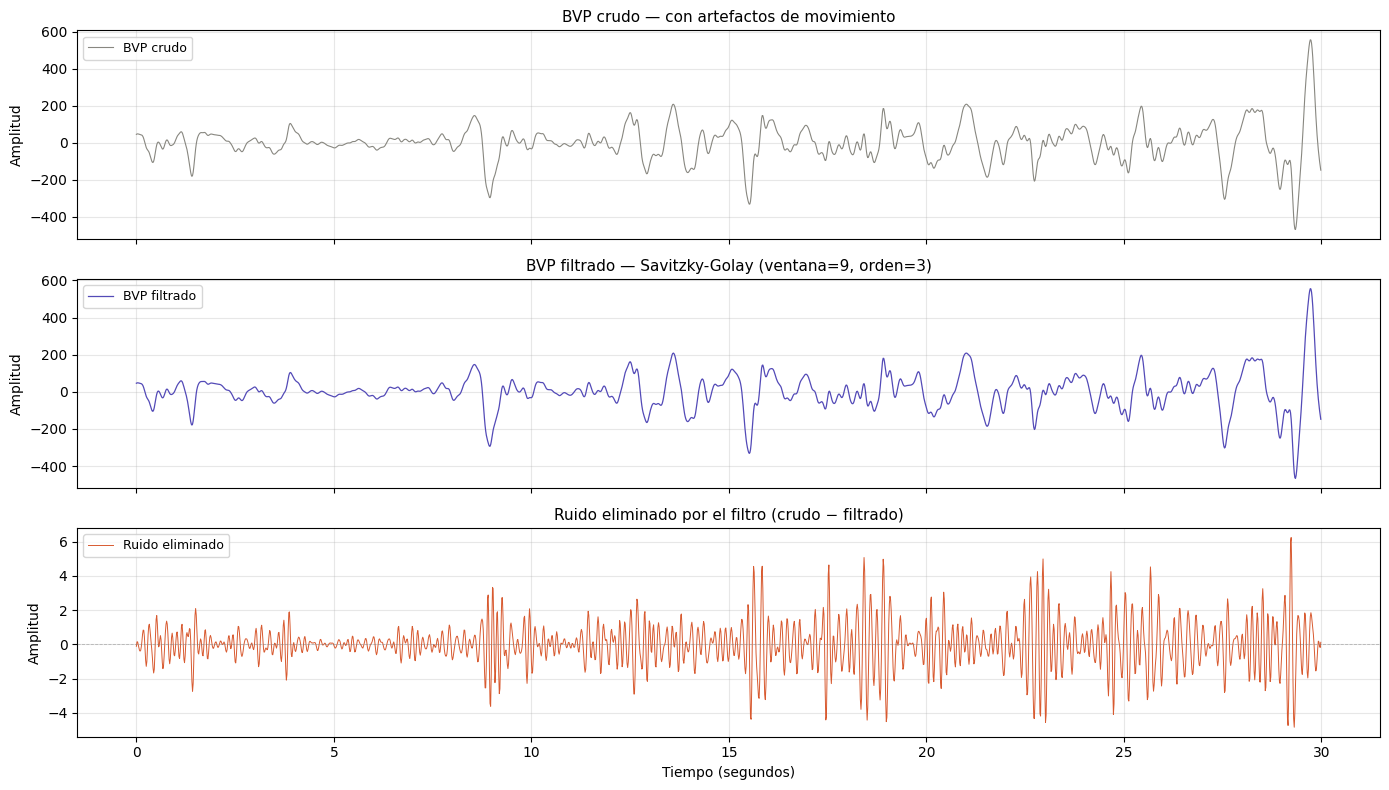

In [60]:
# ============================================================
# Señal BVP cruda vs filtrada (30 segundos)
# ============================================================
from scipy.signal import savgol_filter

df_raw    = pd.read_csv(os.path.join(RUTA_PROYECTO, 'data', 'raw', 'paciente01.csv'))
df_valido = df_raw[~df_raw['Sleep_Stage'].isin(['P','Missing'])].reset_index(drop=True)

# Tomar un segmento del medio de la noche donde hay más movimiento
bvp_crudo    = df_valido['BVP'].values[15000:16920]
bvp_filtrado = savgol_filter(bvp_crudo, window_length=9, polyorder=3)
ruido        = bvp_crudo - bvp_filtrado
tiempo       = np.arange(1920) / 64

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(tiempo, bvp_crudo,    color='#888780', linewidth=0.8, label='BVP crudo')
axes[1].plot(tiempo, bvp_filtrado, color='#534AB7', linewidth=0.9, label='BVP filtrado')
axes[2].plot(tiempo, ruido,        color='#D85A30', linewidth=0.7, label='Ruido eliminado')
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)

titulos = ['BVP crudo — con artefactos de movimiento',
           'BVP filtrado — Savitzky-Golay (ventana=9, orden=3)',
           'Ruido eliminado por el filtro (crudo − filtrado)']

for ax, titulo in zip(axes, titulos):
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Amplitud', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[2].set_xlabel('Tiempo (segundos)', fontsize=10)
plt.tight_layout()
plt.show()

### **Extracción de características**

El último paso en lo que al tratamiento de datos se refiere consistió en la extracción de 50 características de la columna tratada, BVP (presión sanguínea en cada timestamp). Estas se dividen en 5 secciones principales. \1
*   Características relacionadas con la morfología de la onda. Se calcula información como la amplitud (diferencias entre picos y valles), el nodo diacrótico (un punto que indica dónde termina la sístole, que es donde ocurre la contracción cardíaca junto con la expulsión de sangre, y dónde comienza la diástole, que es donde se da la relajación del corazón y su llenado de sangre), tiempo en cada una de las fases, del latido completo y variabilidad; junto con la media y la desviación típica de cada una de las variables.
*   Características basadas en el ritmo y la respiración. A partir de las diferencias entre las amplitudes de los picos, se determinan parámetros como el RIAM (_"Respiration-induced amplitude modulation"_) y el RIFM (_"Respiration-induced frequency modulation"_).
*   Métricas estadísticas y basadas en la energía. Se tienen en cuenta las desviaciones respecto a la mediana o a la media, la intensidad del latido, las medias armónicas y geométrica, los rangos intercuartiles y otras medidas relacionadas con la forma, como la curtosis o el sesgo.
*   Variabilidad del latido. Se toman como referencia las métricas definidas por Poincaré, que permiten identificar cómo de agrupadas y similares son los valores de los latidos; así como la predictibilidad de la función que define la sucesión de estos valores.
*   Variables no lineales. Se utilizan medidas más complejas, como los parámetros de Hjord (inicialmente pensados para encefalogramas, pero que también se aplican en otro tipo de pruebas, como los electrocardiogramas, basados en variaciones temporales) o los fractales (jugando con el análisis de los datos utilizando otro tipo de dimensiones).


In [44]:
# ============================================================
# Extracción de características
# Muestra las features extraídas de X_features.csv
# y un ejemplo visual de detección de picos sobre la señal
# ============================================================
from scipy.signal import find_peaks

# Cargar features ya extraídas por el pipeline
X = pd.read_csv(os.path.join(RUTA_PROYECTO, 'data', 'processed', 'X_features.csv'))
cols_meta = ['id_paciente']
X_clean = X.drop(columns=[c for c in cols_meta if c in X.columns])

print(f"Dimensiones del dataset de features: {X_clean.shape}")
print(f"  → {X_clean.shape[0]} epochs  ×  {X_clean.shape[1]} features\n")

# Tabla resumen de categorías
categorias = {
    'Morfología de la onda':       14,
    'Ritmo y respiración':         12,
    'Estadísticas y energía':      15,
    'Variabilidad cardíaca (HRV)':  4,
    'Complejidad y fractales':      5,
}
df_cat = pd.DataFrame(
    list(categorias.items()),
    columns=['Categoría', 'Nº features']
)
df_cat['% del total'] = (
    df_cat['Nº features'] / df_cat['Nº features'].sum() * 100
).round(1).astype(str) + '%'
df_cat.loc[len(df_cat)] = ['TOTAL', df_cat['Nº features'].sum(), '100%']
print("Resumen de categorías de features:")
display(df_cat)

# Mostrar las primeras 3 filas del dataset de features
print("\nPrimeras 3 filas — primeras 8 features:")
display(X_clean.iloc[:3, :8].round(4))


Dimensiones del dataset de features: (7998, 50)
  → 7998 epochs  ×  50 features

Resumen de categorías de features:


,Categoría,Nº features,% del total
0,Morfología de la onda,14,28.0%
1,Ritmo y respiración,12,24.0%
2,Estadísticas y energía,15,30.0%
3,Variabilidad cardíaca (HRV),4,8.0%
4,Complejidad y fractales,5,10.0%
5,TOTAL,50,100%



Primeras 3 filas — primeras 8 features:


,Mean_A,SD_A,Mean_A1,SD_A1,Mean_A2,SD_A2,Mean_T1,SD_T1
0,10663.0252,17264.3765,8143.7932,12330.6262,2519.2320,8827.8167,0.9200,0.4514
1,8358.4998,15144.7294,7371.7026,12389.5742,986.7972,3461.3733,0.7593,0.2666
2,3000.8361,2506.8649,2564.2634,2179.4712,436.5727,1536.2247,0.6385,0.2529



## **Modelos**

En cuanto a los modelos utilizados, se tomaron como base aquellos referenciados en el artículo. \1
- **eXtreme Gradient Boosting (XGBoost)**
- **Random Forest (RF)**
- **K-Nearest-Neighbours (KNN)**

Con el objetivo de ampliar el alcance del estudio, se ha añadido un cuarto modelo. \1
- **Support Vector Machines (SVM)**, ya utilizado en otros papers similares al de referencia con una precisión razonable.

Los cuatro modelos están implementados en el archivo `src/models.py`, que devuelve cada clasificador configurado con sus hiperparámetros listos para entrenar. Los hiperparámetros de XGBoost, RF y KNN se tomaron directamente del artículo de referencia. SVM se configuró siguiendo la literatura relacionada.


### **Random Forest**

Este método, con una precisión ligeramente inferior que XGB para el problema que se busca resolver, se basa en un concepto similar, aunque difieren en la implementación final, ya que este en lugar de utilizar los estimadores débiles para mejorar y crear uno más rpbusto, lo que hace es ponderar las estimaciones de todos los árboles, que se entrenan de forma independiente, combinándolas al final.  
Sus principales beneficios radican en evitar el overfitting (al ser árboles independientes y ponderar la decisión, es mucho más difícil que se de), y que, al estar basado en árboles, la reconstrucción de la solución es muy sencilla, siendo interesante de cara a cuestiones de trazabilidad y explicabilidad.  
Los hiperparámetros disponibles son bastante similares a los de XGB, habiéndose inicializado originalmente un número de estimadores idéntico (200), aunque con una profundidad mucho mayor (15 en lugar de 8, probablemente para compensar la independencia de los árboles, que no obtendrán datos de los demás con los que mejorar sus predicciones, requiriendo una mayor enjundia).

### **K-Nearest-Neighbours**

En este caso, KNN proporciona una clasificación por similitud, de manera que decidirá a qué clase pertenece una instancia en función de las k más cercanas (vecinos) seleccionadas.
Aunque la precisión es inferior a la de los métodos mencionados, entre sus ventajas más significativas este algoritmo no requiere de una etapa de entrenamiento, ni depende de una gran cantidad de hiperparámetros, ya que su comportamiento viene determinado por estos dos. \1*   **n_neighbors.** Establece el número de vecinos alrededor de la instancia dada que se tendrán en cuenta para realizar la predicción. Es crucial elegor una buena cifra, ya que un número muy bajo de vecinos podría llevar a overfitting (o a soluciones erróneas si se trata de un outlier, ya que sus vecinos se encuentran muy lejos), y uno muy alto podría estar describiendo el comportamiento promedio del conjunto de datos, y no el de la instancia en concreto. Inicialmente, el número de vecinos a tener en cuenta fue de 5, siguiendo la recomendación del propio sklearn.
*   **metric.** Indica cómo se va a calcular la distancia entre vecinos (Manhattan, euclídea, del coseno, etc.). Para este caso, los mejores resultados obtenidos en el paper se dieron seleccionando la distancia euclídea.

### **eXtreme Gradient Boosting**

Este modelo es el que alcanzó mayor precisión en el paper de referencia, se basa en la idea de crear conjuntos de árboles de decisión, convirtiendo estimadores débiles como son los árboles individuales en predictores precisos al llevar asociado un proceso de entrenamiento por el que a través de un sistema de ponderación de pesos se enseña a los árboles los errores cometidos por sus predecesores.

En términos generales este algoritmo es bastante robusto siendo utilizado en tareas que abarcan desde la clasificación hasta el 
forecasting de series temporales. Entre sus mayores virtudes destacan el procesamiento en paralelo, el uso de heurísticas para aumentar la eficiencia y reducir el coste computacional, obteniendo valores aproximados pero precisos.

Los hiperparámetros utilizados se tomaron directamente del artículo de referencia (Rowshon & Motin, 2026), sin aplicar búsqueda 
automática de hiperparámetros (GridSearchCV). Los más relevantes son. \1
- **n_estimators = 200**. Número de árboles del ensemble. El valor 200 es el especificado por los autores del artículo. Aumentarlo 
mejora marginalmente la precisión pero incrementa el tiempo de entrenamiento de forma proporcional.

- **max_depth = 8**. Profundidad máxima de cada árbol es decir el número máximo de niveles de decisión. Un valor de 8 permite 
capturar relaciones complejas entre las 50 features fisiológicas sin incurrir en sobreajuste. Es menor que el de Random Forest
porque en boosting cada árbol aprende de los errores del anterior necesitando menor profundidad individual.

- **eval_metric = mlogloss**. Métrica de evaluación interna durante el entrenamiento. *mlogloss* (logarithmic loss multiclase) es la 
opción correcta para problemas de clasificación con más de 2 clases, como los escenarios de 3 y 4 clases de este estudio. Penaliza más 
las predicciones erróneas con alta confianza que las dudosas.

- **random_state = 42**. Semilla fija para garantizar la reproducibilidad completa de los resultados en cualquier máquina.

### **Support Vector Machine**


Pese a no estar implementada en el artículo de referencia, en otros trabajos citados por los propios autores se destaca la alta precisión que puede alcanzar este algoritmo para el caso actual. Este algoritmo se basa en la creación de un hiperplano (límite de decisión) que maximice el margen entre instancias de clases distintas.  
Su principal punto fuerte es la versatilidad, ya que su implementación le permite abordar situaciones no lineales, trasladando las características a un plano N-dimensional. Asimismo, SVM destaca por su robusta capacidad de generalización y su resistencia al sobreentrenamiento (overfitting). 

Para que funcione adecuadamente, es necesario seleccionar un número correcto de hiperparámetros, entre los que se encuentran. \1*   **kernel.** Indica cómo se va a construir el límite de decisión (si va a ser lineal, polinómico, etc.).
*   **C.** Sirve para ajustar el proceso de regularización, es decir, cómo la adición de más instancias también afecta a la penalización total. Cuanto mayor es este parámetro, menos estricto es este proceso de regularización (por defecto, la librería establece un 1).
*   **gamma.** Ajusta la función del kernel en función del número de features.
*   **class_weight.** Establece los valores de C en función del número de clases.

#### ***Métricas de rendimiento***

Pese a tener una gran cantidad de modelos, su implementación no es útil si no hay ninguna forma de comparar su desempeño. Para ello se han definido una serie de métricas, que evalúan el comportamiento de cada algoritmo. \1*   **Matriz de confusión.** Pese a no ser una métrica al uso, proporciona una intuición bastante buena del comportamiento del modelo a través del análisis de falsos positivos y falsos negativos, algo realmente útil de cara a evaluar si, por ejemplo, un modelo tiene problemas para distinguir entre dos clases concretas, debiendo abordar la aproximación actual para resolverlo. Todas las métricas se basan en ella.
*   **Accuracy.** Esta métrica genérica se utiliza para evaluar el total de casos predichos correctamente del total de casos, proporcionando una intuición de lo bien que funciona el modelo. Sin embargo, esta métrica puede resultar engañosa, ya que, si se hablara de un caso de detección de transacciones fraudulentas en el que casi todas son negativas, un modelo que clasifique todas como negativas tendría un accuracy de casi el 100%, aunque realmente su desempeño sería terrible.
*   **Precision.** Se basa en la matriz de confusión para identificar cómo de bien ha predicho las clases, ponderando uno por uno los casos en los que predijo adecuadamente divididos por la suma de todos (los correctos e incorrectos).
*   **Sensitivity.** También conocida como recall, basada en la matriz de confusión, en este caso se mide la proporción de predicciones correctas identificadas por el modelo a través del cociente entre las correctas y la suma de correctas e incorrectas (falsos negativos).
*   **Specificity.** Esta métrica se centra en conocer del total de casos negativos, cuáles fueron identificados correctamente como negativos y cuáles se confundieron y terminaron siendo falsos positivos. 
*   **F-1 score.** Cálculo ponderado (media armónica) entre precision y recall. Esta es la métrica más orientativa, ya que una precision muy alta pero una recall muy baja supone una precisión muy buena pero un gran número de fallos; y viceversa.

#### ***Resultados obtenidos***

La siguiente tabla muestra las 5 métricas calculadas para los 
4 modelos en los 3 escenarios de clasificación.

In [45]:
# ============================================================
# Resultados de los modelos (3 escenarios)
# Carga el CSV generado por run_pipeline.py
# ============================================================

df_resultados = pd.read_csv(
    os.path.join(RUTA_PROYECTO, 'outputs', 'resultados_completos.csv'),
    index_col=0
)

print("Tabla de resultados completa:")
display(df_resultados[['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1-Score']])

Tabla de resultados completa:


,Accuracy,Precision,Sensitivity,Specificity,F1-Score
RF_2cls,84.69%,81.60%,73.14%,73.14%,83.52%
KNN_2cls,83.69%,78.47%,73.92%,73.92%,82.98%
XGBOOST_2cls,84.56%,79.81%,75.31%,75.31%,83.93%
SVM_2cls,79.94%,73.19%,76.76%,76.76%,80.65%
RF_3cls,77.50%,76.66%,59.00%,81.20%,75.41%
KNN_3cls,76.88%,71.37%,62.41%,82.02%,75.66%
XGBOOST_3cls,78.94%,75.71%,65.86%,83.49%,77.97%
SVM_3cls,68.00%,60.26%,69.02%,83.01%,69.77%
RF_4cls,72.25%,74.74%,56.49%,85.51%,70.49%
KNN_4cls,69.44%,64.39%,58.53%,85.29%,68.36%


#### ***Comparativa con el artículo de referencia***

La siguiente tabla compara los resultados obtenidos con los publicados en el artículo de referencia (Rowshon & Motin, 2026) 
para los tres modelos comunes: RF, KNN y XGBoost. SVM no aparece en el artículo original y se muestra únicamente como extensión propia.

Una diferencia menor de 3 puntos porcentuales en accuracy y F1 se considera una réplica correcta en estudios de clasificación de 
señales fisiológicas, especialmente considerando que el artículo omitió detallar la identidad o los criterios de selección de la muestra de 10 sujetos extraída de los 100 registros disponibles en el dataset original.

In [46]:
# ============================================================
# Comparativa con el artículo de referencia
# Rowshon & Motin (2026) — Tabla II
# ============================================================

comparativa = pd.DataFrame({
    'Escenario': [
        '2 clases', '2 clases', '2 clases',
        '3 clases', '3 clases', '3 clases',
        '4 clases', '4 clases', '4 clases'
    ],
    'Modelo': [
        'RF', 'KNN', 'XGBoost',
        'RF', 'KNN', 'XGBoost',
        'RF', 'KNN', 'XGBoost'
    ],
    'Accuracy artículo': [
        '84.50%', '81.19%', '83.75%',
        '76.19%', '74.81%', '78.25%',
        '71.25%', '67.25%', '74.62%'
    ],
    'Accuracy obtenido': [
        '84.69%', '83.69%', '84.56%',
        '77.50%', '76.88%', '78.94%',
        '72.25%', '69.44%', '73.06%'
    ],
    'F1 artículo': [
        '83.30%', '80.35%', '83.00%',
        '74.01%', '73.67%', '77.40%',
        '69.10%', '66.22%', '73.75%'
    ],
    'F1 obtenido': [
        '83.52%', '82.98%', '83.93%',
        '75.41%', '75.66%', '77.97%',
        '70.49%', '68.36%', '72.05%'
    ],
})

print("Comparativa resultados obtenidos vs artículo de referencia:")
display(comparativa)

# Calcular diferencias
acc_art = comparativa['Accuracy artículo'].str.replace('%','').astype(float)
acc_obt = comparativa['Accuracy obtenido'].str.replace('%','').astype(float)
f1_art  = comparativa['F1 artículo'].str.replace('%','').astype(float)
f1_obt  = comparativa['F1 obtenido'].str.replace('%','').astype(float)

diff_acc = (acc_obt - acc_art).abs()
diff_f1  = (f1_obt  - f1_art).abs()

print(f"\nDiferencia media en Accuracy: {diff_acc.mean():.2f} pp")
print(f"Diferencia media en F1-Score: {diff_f1.mean():.2f} pp")
print(f"Diferencia máxima en Accuracy: {diff_acc.max():.2f} pp")

Comparativa resultados obtenidos vs artículo de referencia:


,Escenario,Modelo,Accuracy artículo,Accuracy obtenido,F1 artículo,F1 obtenido
0,2 clases,RF,84.50%,84.69%,83.30%,83.52%
1,2 clases,KNN,81.19%,83.69%,80.35%,82.98%
2,2 clases,XGBoost,83.75%,84.56%,83.00%,83.93%
3,3 clases,RF,76.19%,77.50%,74.01%,75.41%
4,3 clases,KNN,74.81%,76.88%,73.67%,75.66%
5,3 clases,XGBoost,78.25%,78.94%,77.40%,77.97%
6,4 clases,RF,71.25%,72.25%,69.10%,70.49%
7,4 clases,KNN,67.25%,69.44%,66.22%,68.36%
8,4 clases,XGBoost,74.62%,73.06%,73.75%,72.05%



Diferencia media en Accuracy: 1.37 pp
Diferencia media en F1-Score: 1.44 pp
Diferencia máxima en Accuracy: 2.50 pp


#### ***Matrices de confusión - XGBoost***

Las matrices de confusión muestran, de cada 100 epochs reales de una fase del sueño, cuántos clasificó correctamente el modelo 
y cuántos confundió con otra fase. Cada fila es una fase real y cada columna es lo que predijo el modelo. Los números de la diagonal son los aciertos, cuanto más altos mejor. Los números fuera de la diagonal son los errores cuanto más bajos mejor.

Se observa que conforme aumenta el número de clases la tarea se vuelve más difícil, especialmente para Deep Sleep (N3) en el 
escenario de 4 clases, donde el modelo solo acierta el 40.4% debido al escaso número de epochs de entrenamiento disponibles: N3 representa solo 578 de los 7.998 epochs totales (7.2%), frente a los 3.966 de Light Sleep (49.6%).

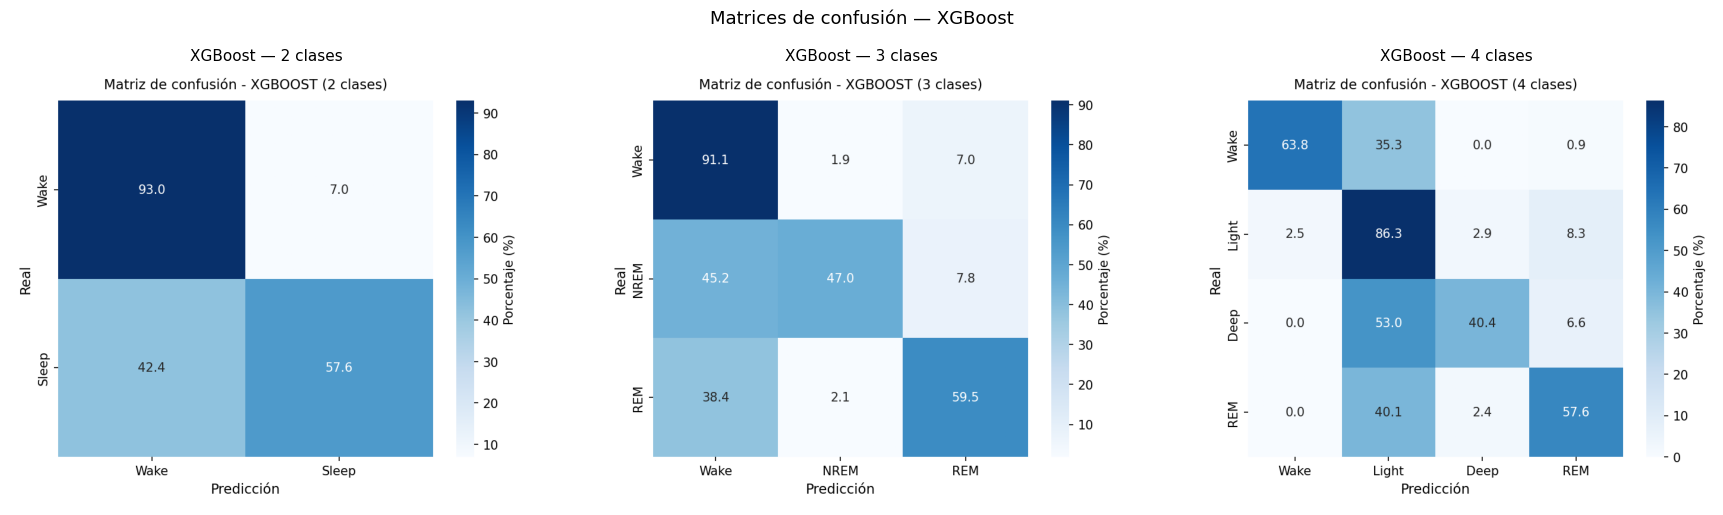

In [47]:
# ============================================================
# Matrices de confusión XGBoost (3 escenarios)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, n_cls in enumerate([2, 3, 4]):
    ruta_img = os.path.join(
        RUTA_PROYECTO, 'outputs', 'plots',
        f'matriz_xgboost_{n_cls}_clases.png'
    )
    img = mpimg.imread(ruta_img)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f'XGBoost — {n_cls} clases', fontsize=11)

plt.suptitle('Matrices de confusión — XGBoost', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## **Explicabilidad**
La otra mejora sustancial respecto al artículo de referencia consiste en la inclusión de técnicas de explicabilidad, tanto a nivel global como local, fundamentadas principalmente en SHAP y LIME. Pese a que en el trabajo mencionado también se empleó LIME, en ese caso fue de forma superficial, solo para identificar, de entre todas las features extraídas, cuáles eran las más relevantes para la predicción (explicación global).   

### **LIME Global**
La primera técnica de explicabilidad aplicada fue LIME. Esta se basa en la elección aleatoria de instancias del conjunto de datos de entrenamiento para generar perturbaciones individualmente. De esta forma, para cada instancia se calcula la importancia relativa de cada uno de sus atributos en la predicción en función de los resultados en esas perturbaciones, y finalmente se realiza una media en valor absoluto de los pesos calculados para cada instancia para obtener la importancia global de cada feature, graficando las 15 más importantes. Con esto, se convierte un método de explicación local (al estar basado en explicar instancias individuales) en uno global, ya que proporciona una intuición del comportamiento del modelo.  

En cuanto a los resultados, las 5 features más importantes según la explicación global son. \1
*   **RIAM_sd (Respiration-induced amplitude modulation).** Comprende la amplitud (diferencia entre pico más alto y valle más bajo) de la respiración inducida a partir del volumen de la presión sanguínea (BVP).
*   **SD_A.** Es la desviación típica de la amplitud (de nuevo, diferencia entre el valor más alto y el más bajo, en este caso directamente sobre la medida del BVP).
*   **HCPPG (Complejidad de Hjorth).** Se define como el cociente de la variación temporal de la movilidad de Hjorth respecto a la media de la movilidad, estando la movilidad muy relacionada, a su vez, con las diferencias de las amplitudes en función de la temporalidad.
*   **PPI_sd.** Se encarga de medir la desviación del intervalo entre pulsos completos.
*   **GmPPG.** Es la media geométrica de los valores de BVP filtrados.

De las 5 features más importantes, 2 pertenecen al bloque de ritmo y respiración, 1 a morfología de la onda, 1 a estadísticas y energía 
y 1 a métricas no lineales. Destaca que las features de variabilidad cardíaca (HRV - Poincaré) no aparecen en el top-5, lo que sugiere 
que para este dataset la información respiratoria y morfológica es más discriminativa que la variabilidad cardíaca clásica.

La diversidad de bloques representados es un resultado positivo. \1cada feature aporta al modelo una perspectiva diferente del mismo momento fisiológico. Por ejemplo, la desviación típica de las 
amplitudes (SD_A) puede ser determinante para identificar una mala conciliación del sueño, constantes despertares y transiciones entre 
fases generan alta variabilidad, mientras que la movilidad de Hjorth (HCPPG) y el intervalo entre pulsos (PPI_sd) capturan 
dimensiones complementarias del mismo fenómeno.

En definitiva, el modelo prioriza features que capturan la variabilidad e irregularidad de la señal cardíaca y respiratoria, 
frente a métricas de forma como las de Poincaré, más centradas en la distribución estática de los valores que en su 
evolución temporal.


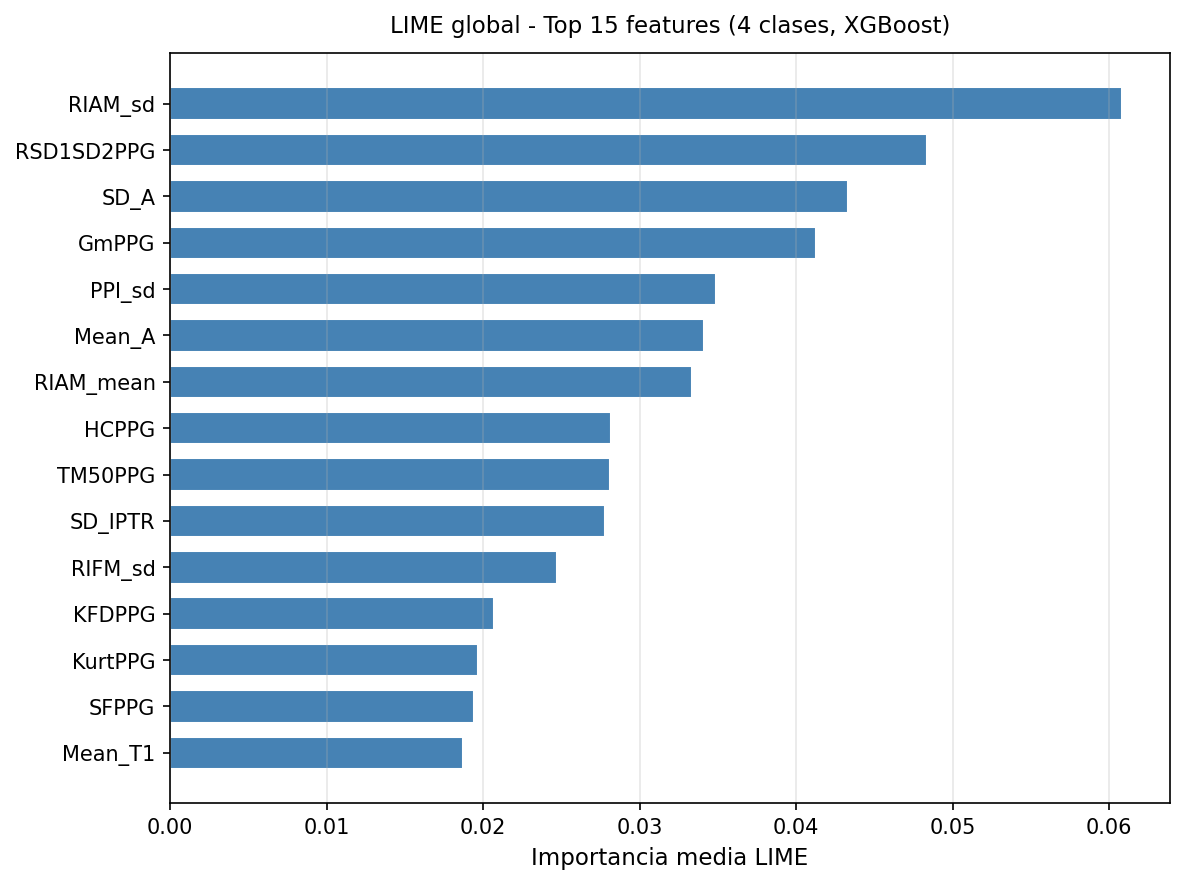

Top 10 features más importantes según LIME global:


,feature,mean_abs_weight
0,RIAM_sd,0.06084
1,RSD1SD2PPG,0.04836
2,SD_A,0.04329
3,GmPPG,0.04130
4,PPI_sd,0.03490
5,Mean_A,0.03411
6,RIAM_mean,0.03333
7,HCPPG,0.02820
8,TM50PPG,0.02813
9,SD_IPTR,0.02781


In [62]:
# ============================================================
# LIME global — top 15 features más importantes
# Solo disponible para 4 clases (escenario más complejo)
# ============================================================

display(Image(os.path.join(RUTA_PROYECTO, 'outputs', 'plots', 'lime_global_4_clases.png')))

df_lime = pd.read_csv(
    os.path.join(RUTA_PROYECTO, 'outputs', 'plots', 'lime_global_importancias_4_clases.csv')
)
print("Top 10 features más importantes según LIME global:")
display(df_lime.head(10).round(5))

### **LIME local**

Adicionalmente, se proporciona la posibilidad de realizar explicaciones sobre instancias concretas (de hecho, se extrae una durante la ejecución del proceso, a modo de prueba). Esto resulta especialmente útil para aquellos usuarios especializados, que tengan claro que en una cierta etapa el modelo se ha equivocado, de manera que puedan determinar cuáles fueron las variables que más influyeron en esa predicción, por si fuera necesario realizar ajustes en la extracción, estuviera mal configurada la selección de los vecindarios de LIME y casuísticas similares.  

A modo de ejemplo, se analiza el epoch 15 del conjunto de prueba en el escenario de 4 clases. El gráfico siguiente muestra las 15 características (features) con mayor contribución a la predicción de ese bloque concreto, identificando en verde aquellas que favorecen la clase predicha y en rojo las que disminuyen su probabilidad.


Epoch 15
  Etiqueta real:   Light
  Clase predicha:  Wake
  Probabilidades:
    Deep: 0.0%
    Light: 0.8%
    REM: 1.1%
    Wake: 98.0%


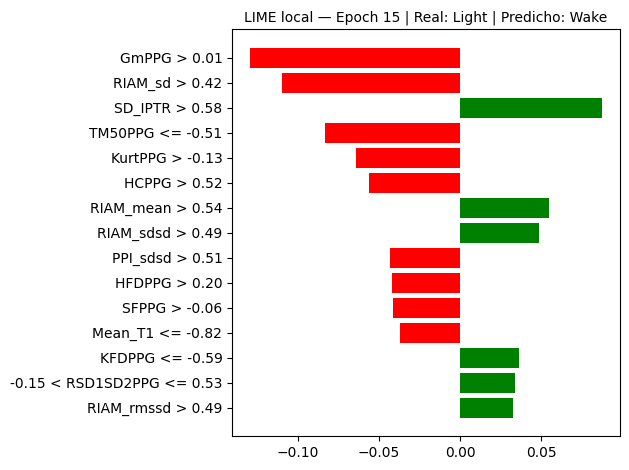

In [49]:
# ============================================================
# LIME local — explicación de un epoch concreto
# Epoch 15 del conjunto de prueba — escenario 4 clases
# ============================================================
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import yaml

# Cargar configuración y datos
with open(os.path.join(RUTA_PROYECTO, 'configs', 'config.yaml')) as f:
    cfg = yaml.safe_load(f)

from src.utils import preprocesar_dataset, obtener_clases_ordenadas
from src.models import configurar_modelo

X_raw = pd.read_csv(os.path.join(RUTA_PROYECTO, 'data', 'processed', 'X_features.csv'))
y_raw = pd.read_csv(os.path.join(RUTA_PROYECTO, 'data', 'processed', 'y_labels.csv'))['Sleep_Stage'].values

cols_meta = ['id_paciente']
X_clean = X_raw.drop(columns=[c for c in cols_meta if c in X_raw.columns])

num_clases       = 4
clases_ordenadas = obtener_clases_ordenadas(num_clases)

X_train, X_test, y_train_str, y_test_str = preprocesar_dataset(
    X_clean, y_raw, num_clases, test_size=0.20, random_state=42
)

le      = LabelEncoder()
y_train = le.fit_transform(y_train_str)
y_test  = le.transform(y_test_str)
clases  = le.classes_

# Cargar modelo XGBoost entrenado
import joblib
modelo_xgb = joblib.load(
    os.path.join(RUTA_PROYECTO, 'outputs', 'models', 'xgboost_4_clases.pkl')
)

# LIME local — epoch 15
EPOCH = 15
instancia   = X_test.iloc[EPOCH].values
etiq_real   = y_test_str[EPOCH]
pred_proba  = modelo_xgb.predict_proba(X_test.iloc[[EPOCH]])[0]
pred_clase  = clases[pred_proba.argmax()]

print(f"Epoch {EPOCH}")
print(f"  Etiqueta real:   {etiq_real}")
print(f"  Clase predicha:  {pred_clase}")
print(f"  Probabilidades:")
for c, p in zip(clases, pred_proba):
    print(f"    {c}: {p*100:.1f}%")

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=clases.tolist(),
    mode='classification',
    random_state=42
)

exp = explainer.explain_instance(
    data_row=instancia,
    predict_fn=modelo_xgb.predict_proba,
    num_features=15
)

fig = exp.as_pyplot_figure()
plt.title(
    f'LIME local — Epoch {EPOCH} | Real: {etiq_real} | Predicho: {pred_clase}',
    fontsize=10
)
plt.tight_layout()
plt.savefig(
    os.path.join(RUTA_PROYECTO, 'outputs', 'plots', f'lime_local_epoch{EPOCH}_notebook.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

### **SHAP**
Esta técnica se basa en calcular los valores Shapley de cada una de las featues para ver cuánto contribuye cada una al resultado final. Para ello, se van probando subconjuntos de features, y aquellas que no pertenecen al subconjunto toman valores aleatorios (esto puede provocar combinaciones irreales, el mismo problema que sufre LIME con sus perturbaciones). Después, para cada caso se obtiene la predicción del modelo, de manera que se calcula cuánto contribuye cada variable a la predicción (puede haber contribuciones negativas en las que la variable "empuja" a una menor probabilidad). La puntuación obtenida no es probabilidad directamente, sino que, al basarse SHAP en una serie de axiomas matemáticos, esta puntuación corresponde al log-odds, y la probbailidad a partir de él se obtendría de la siguiente forma. \1
            `p = 1 / (1 + exp(-log_odds))`

Para los modelos implementados basados en árboles, como XGBoost o Random Forest, SHAP proporciona una librería específica, el TreeExplainer, que aprovecha la estructura de árbol construída a partir de los datos de entrenamiento. Cuando llega una nueva instancia, en caso de que no exista la característica de una de las ramas, se utiliza un sistema de ponderación para calcular cuál sería, en log-odds, la puntuación asociada a esa variable. De este modo, el cálculo es verdaderamente prático y eficiente.

En este caso, tomando como referencia las contribuciones globales (la suma de las contribuciones de cada variable para cada clase), las 5 más importantes son. \1
1. **HCPPG (Hjorth):** la feature más importante con diferencia. Contribuye de forma equilibrada 
a las 4 clases, lo que la convierte en el discriminador universal más potente del modelo.

2. **PPI_mean:**  media del intervalo entre latidos. Especialmente relevante para distinguir Deep Sleep (latidos lentos y espaciados) de Wake (latidos rápidos).

3. **GmPPG:**  media geométrica de la señal BVP filtrada. Representa el nivel energético medio del pulso.

4. **Mean_T1:** duración media de la fase sistólica (tiempo de subida del pulso). Varía con la profundidad 
del sueño al cambiar el tono vascular.

5. **RSD1SD2PPG:** ratio entre la variabilidad cardíaca a corto y largo plazo (Poincaré SD1/SD2). Mide el equilibrio entre el sistema nervioso simpático y parasimpático.

Pese a que la relevancia predictiva de estas variables fluctúa en función de la etapa del sueño analizada, esta jerarquía general denota una clara preponderancia de los descriptores asociados al ritmo cardíaco y la modulación respiratoria (representando tres de las cinco variables principales). Por su parte, las dos métricas restantes se distribuyen equitativamente entre las dimensiones de análisis estadístico-energético y dinámicas no lineales.

La explicación de este resultado puede ser bastante parecida a la de LIME en lo que se refiere a considerar cuál de las 5 dimensiones le aporta más información al modelo. En este caso, parece que la respiración (tanto las variaciones como la media de los valores) y el intervalo entre pulsos lo considera bastante determinante, algo que tiene sentido, pues la respiración también se vuelve más lenta conforme más profundo es el sueño, por lo que no es descabellado que el modelo utilice esta idea para ayudar a tomar la decisión final.


El gráfico siguiente muestra la importancia media del valor SHAP para cada feature, desglosada por clase del sueño. A diferencia 
del gráfico de LIME (que muestra un único valor global), SHAP permite ver qué features son más importantes para detectar 
cada fase concreta. \1
- **Azul (Deep)**: features clave para detectar sueño profundo
- **Morado (REM)**: features clave para detectar sueño REM  
- **Rojo (Wake)**: features clave para detectar vigilia
- **Verde (Light)**: features clave para detectar sueño ligero

Por ejemplo, **HCPPG** es la feature más importante globalmente y contribuye de forma equilibrada a todas las clases, lo que 
indica que la complejidad de Hjorth es un discriminador universal entre fases. En cambio, **PPI_mean** tiene mayor peso para Deep 
y REM que para Wake, lo que tiene sentido fisiológico: el intervalo entre latidos es más largo y estable en sueño profundo que en vigilia.

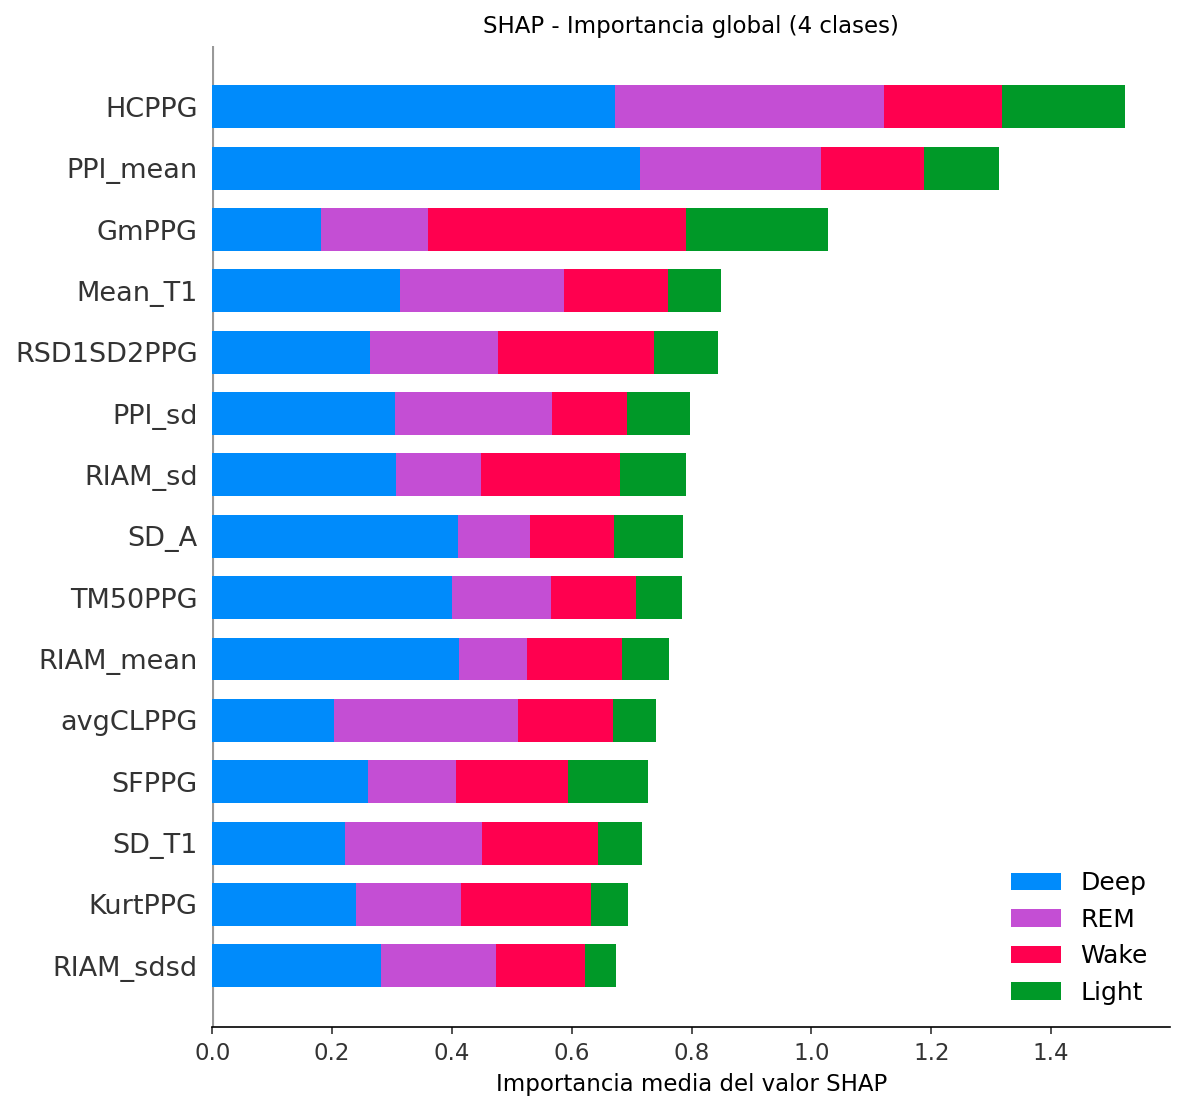

Comparativa top-5 features — LIME vs SHAP (4 clases, XGBoost):


,Posición,LIME top-5,SHAP top-5,Coincide
0,1,RIAM_sd,HCPPG,No
1,2,SD_A,PPI_mean,No
2,3,HCPPG,RIAM_sd,✓ Sí
3,4,PPI_sd,RIAM_mean,No
4,5,GmPPG,GmPPG,✓ Sí



Features coincidentes en ambos métodos: HCPPG, RIAM_sd, GmPPG


In [63]:
# ============================================================
# SHAP global 
# ============================================================

display(Image(os.path.join(RUTA_PROYECTO, 'outputs', 'plots', 'shap_global_4_clases.png')))

comparativa_xai = pd.DataFrame({
    'Posición': [1, 2, 3, 4, 5],
    'LIME top-5':   ['RIAM_sd', 'SD_A', 'HCPPG', 'PPI_sd', 'GmPPG'],
    'SHAP top-5':   ['HCPPG', 'PPI_mean', 'RIAM_sd', 'RIAM_mean', 'GmPPG'],
    'Coincide':     ['No', 'No', '✓ Sí', 'No', '✓ Sí'],
})

print("Comparativa top-5 features — LIME vs SHAP (4 clases, XGBoost):")
display(comparativa_xai)
print("\nFeatures coincidentes en ambos métodos: HCPPG, RIAM_sd, GmPPG")

- De las 5 características más importantes, en ambos métodos **HCPPG**, **RIAM_sd** y **GmPPG** forman parte del top-5, 
aunque no necesariamente en el mismo orden de importancia. HCPPG ocupa la posición 3 en LIME y la 1 en SHAP, mientras 
que GmPPG coincide exactamente en la posición 5 en ambos.

- LIME sitúa en primer lugar **RIAM_sd** (variabilidad de la modulación respiratoria) mientras que SHAP coloca primero 
**HCPPG** (complejidad de Hjorth). Esta diferencia refleja que LIME es más sensible a la variabilidad local de la señal 
mientras que SHAP capta mejor las relaciones globales entre features.

- LIME incluye **SD_A** y **PPI_sd** en su top-5 mientras que SHAP prefiere **PPI_mean** y **RIAM_mean**. En ambos 
casos son features del mismo bloque fisiológico, la diferencia está en si el modelo usa la media o la desviación 
como indicador más discriminativo.

- En ambos casos el bloque de **ritmo y respiración** es el más representado: 2 features en LIME (RIAM_sd, PPI_sd) 
y 3 en SHAP (RIAM_sd, RIAM_mean, PPI_mean).



En términos generales que los resultados sean bastante similares suele ser un buen síntoma, ya que parece que ambos métodos consideran como importantes subconjuntos muy parecidos. Pero hay que tener cuidado porque no deja de ser una intuición, y en ambos pueden generar combinaciones irreales que alteren los resultados (o den más importancia a unas features que a otras pese a que eso no ocurra así en la realidad) o podrían estar obteniendo atajos estadísticos sesgados. La última palabra debería tenerla un experto, que seleccione y valide casos concretos, pero es sin duda un muy buen punto de partida de cara a identificar posibles discrepancias entre los métodos de explicabilidad que puedan indicar que algo no va bien.

### **Permutation Importance**

A diferencia de LIME y SHAP, que solo se aplican sobre XGBoost, Permutation Importance se calculó para los 4 modelos porque funciona con cualquier clasificador sin necesidad de acceder a su estructura interna.

El método es conceptualmente sencillo: para cada feature, se barajan aleatoriamente sus valores en el conjunto de prueba 30 veces y se mide cuánto cae la accuracy en cada barajada. La caída media es la importancia de esa feature si al romper la relación entre esa feature y la etiqueta el modelo empeora mucho, significa que dependía de ella para clasificar correctamente.

Los gráficos muestran las top-15 features más importantes para cada modelo en el escenario de 4 clases. Las barras de error 
indican la variabilidad entre las 30 repeticiones barras cortas significan una importancia estable y fiable.

#### ***Interpretación de los resultados:***

Comparando los 4 gráficos se observan dos patrones principales. \1
**Convergencia:** **HCPPG** aparece como la feature más importante o entre las primeras en los 4 modelos. Esto confirma el 
resultado de LIME y SHAP, la complejidad de Hjorth es el discriminador más robusto entre fases del sueño con independencia 
del tipo de modelo utilizado.

**Divergencia en SVM:** SVM muestra un ranking diferente al de los modelos basados en árboles. Esto es esperable, SVM construye 
su frontera de decisión de forma diferente (hiperplano en espacio transformado) y puede depender de combinaciones de features 
distintas para llegar a la misma predicción.

Esta comparativa entre modelos tiene valor clínico: si una feature aparece como importante en todos los modelos, es una señal 
fisiológica robusta y no un artefacto del algoritmo concreto.

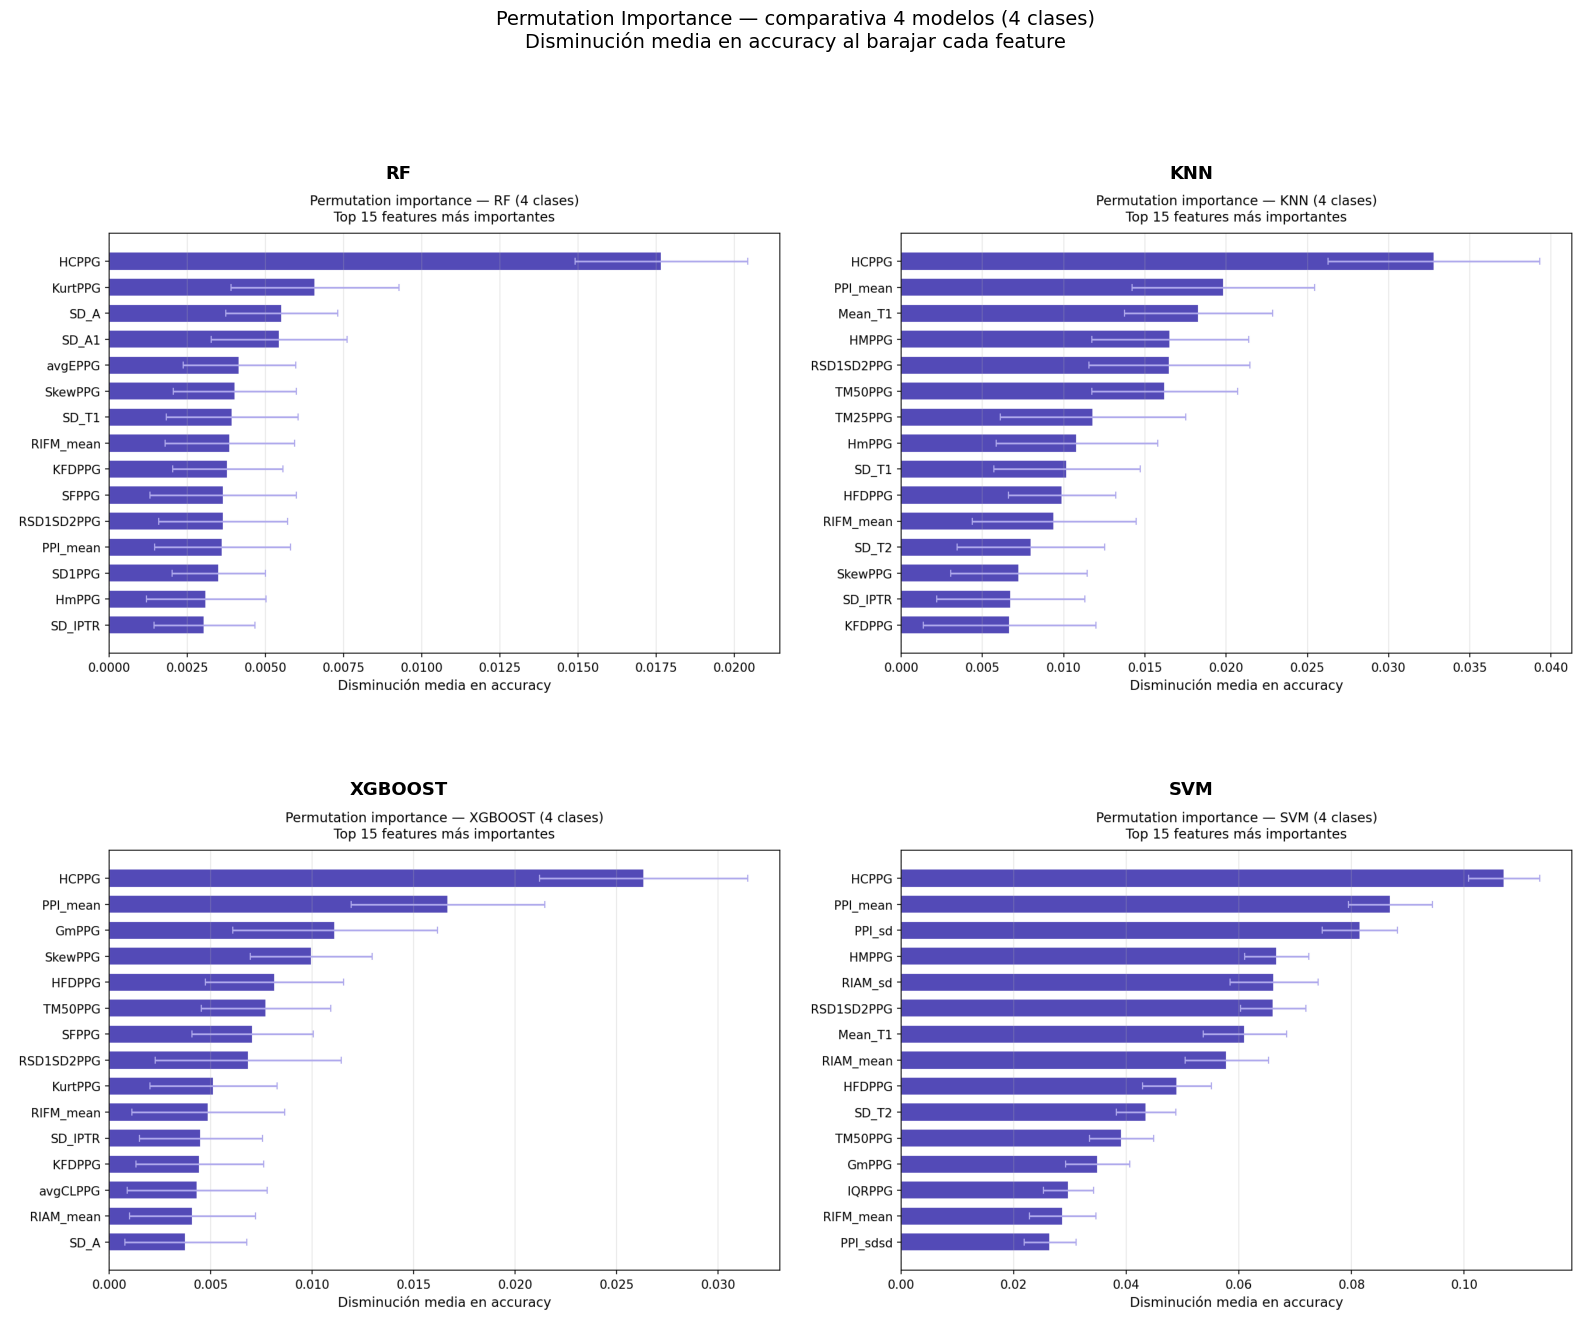

In [64]:
# ============================================================
# Permutation Importance — comparativa 4 modelos
# Escenario de 4 clases
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))  # ← 2 filas x 2 columnas
axes_flat = axes.ravel()

for idx, alg in enumerate(['rf', 'knn', 'xgboost', 'svm']):
    ruta_img = os.path.join(
        RUTA_PROYECTO, 'outputs', 'plots',
        f'permutation_importance_{alg}_4_clases.png'
    )
    if os.path.exists(ruta_img):
        img = mpimg.imread(ruta_img)
        axes_flat[idx].imshow(img)
        axes_flat[idx].axis('off')
        axes_flat[idx].set_title(alg.upper(), fontsize=13, fontweight='bold')
    else:
        axes_flat[idx].text(0.5, 0.5, f'No encontrado:\n{alg}',
                            ha='center', va='center', fontsize=9)
        axes_flat[idx].axis('off')

plt.suptitle(
    'Permutation Importance — comparativa 4 modelos (4 clases)\n'
    'Disminución media en accuracy al barajar cada feature',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

### **PDP - Partial Dependence Plot**

El PDP es la técnica de explicabilidad más intuitiva de las cuatro aplicadas. Mientras que LIME y SHAP responden a la pregunta Qué features importan más?, el PDP responde a Cómo afecta el valor concreto de una feature a la predicción?.

Para cada feature seleccionada (las top-6 más importantes según Permutation Importance), el PDP varía su valor de mínimo a máximo 
manteniendo el resto de features constantes y mide cómo cambia la probabilidad de predecir cada clase. Solo se aplica a XGBoost 
por ser el modelo con mejor rendimiento.

Se genera un gráfico por cada clase del sueño analizada.

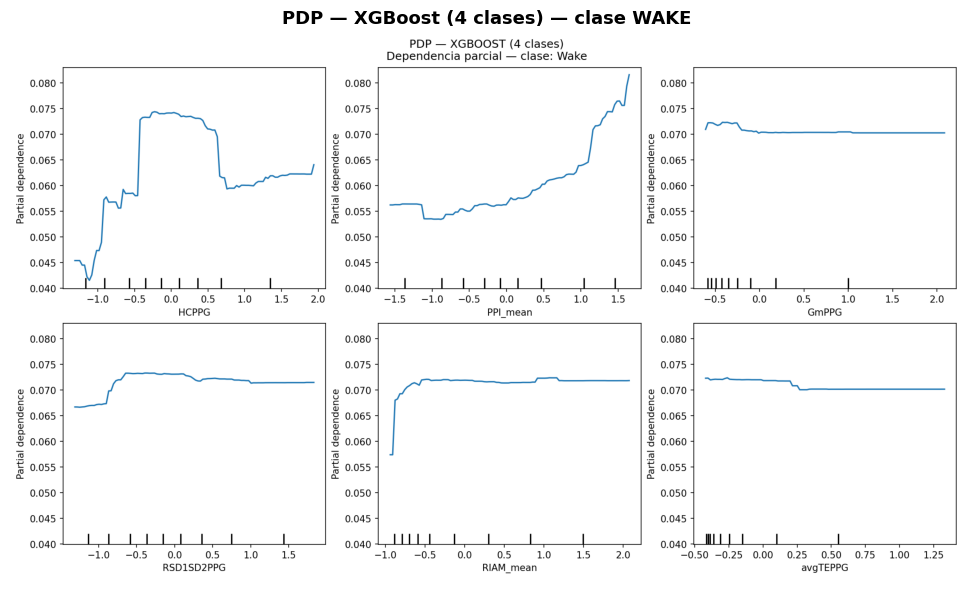

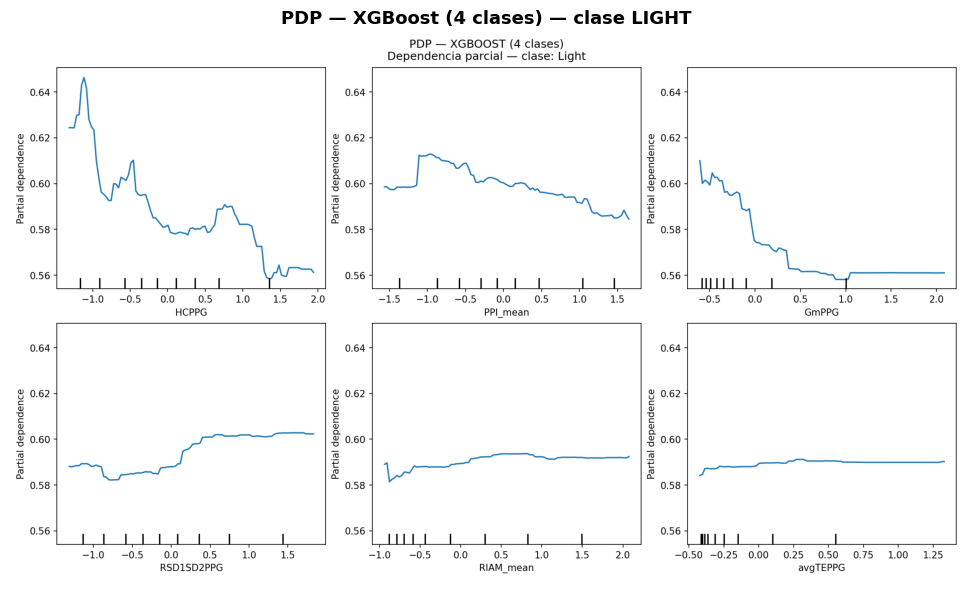

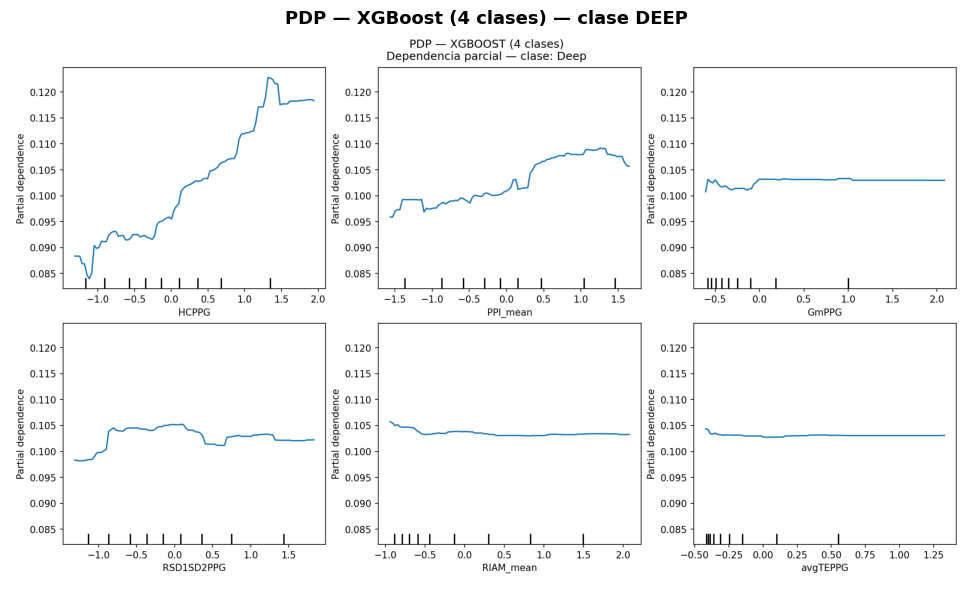

In [52]:
# ============================================================
# PDP (Partial Dependence Plot) — XGBoost
# Muestra cómo afecta el valor de cada feature a la predicción
# Se genera un gráfico por clase del sueño
# ============================================================

for clase in ['wake', 'light', 'deep']:
    ruta_img = os.path.join(
        RUTA_PROYECTO, 'outputs', 'plots',
        f'pdp_xgboost_4_clases_{clase}.png'
    )
    if os.path.exists(ruta_img):
        fig, ax = plt.subplots(figsize=(14, 6))
        img = mpimg.imread(ruta_img)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f'PDP — XGBoost (4 clases) — clase {clase.upper()}',
            fontsize=13, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()
    else:
        print(f"No encontrado: {ruta_img}")

#### ***Interpretación de los gráficos PDP***

Cada subgráfico muestra en el eje X el rango de valores de una feature y en el eje Y la probabilidad de predecir esa 
clase. Una curva creciente significa que valores altos de esa feature aumentan la probabilidad de predecir esa clase. Una 
curva decreciente significa lo contrario.

**Clase WAKE (vigilia):**
- **HCPPG alto** → mayor probabilidad de Wake. Fisiológicamente correcto: la señal cardíaca es más compleja e irregular cuando 
el paciente está despierto.

- **PPI_mean bajo** → mayor probabilidad de Wake. Los latidos más rápidos y frecuentes son típicos de la vigilia.

**Clase LIGHT (sueño ligero):**
- Las curvas son más planas que en Wake, lo que indica que Light Sleep es una clase de transición, las features no tienen 
un patrón tan marcado como en vigilia o sueño profundo.

- GmPPG muestra una relación positiva: valores medios de energía del pulso caracterizan el sueño ligero.

**Clase DEEP (sueño profundo):**
- **HCPPG bajo** → mayor probabilidad de Deep. La señal es más simple y predecible en sueño profundo, el sistema nervioso 
autónomo regula el corazón de forma más estable.
- **PPI_mean alto** → mayor probabilidad de Deep. Los latidos son más lentos y espaciados durante el sueño profundo.

HCPPG y PPI_mean tienen comportamientos opuestos entre Wake y Deep. Los valores altos predicen vigilia y valores bajos predicen sueño profundo. Esto es coherente con la fisiología del sueño y valida que el modelo está aprendiendo patrones reales y no atajos falsos basados en coincidencias del dataset.

## **Conclusiones**

**- Réplica correcta del artículo**: XGBoost alcanza 84.56% (2 clases), 78.94% (3 clases) y 73.06% (4 clases), con diferencias menores de 2 pp respecto al artículo de referencia. Esto valida que el pipeline implementado es fiel a la metodología original.

**- Convergencia LIME–SHAP**: Tres de las cinco features más importantes coinciden en ambos métodos (HCPPG, RIAM_sd, GmPPG), lo que valida la robustez de las conclusiones sobre qué información fisiológica es más discriminativa.

**- Las features de ritmo y respiración dominan**: En todos los métodos XAI, las métricas del grupo de ritmo y respiración (RIAM_sd, RIAM_mean, PPI_mean) aparecen entre las más importantes, lo que es coherente fisiológicamente — la respiración se ralentiza progresivamente con la profundidad del sueño, dejando una huella clara en la señal BVP.

**- Extensión con SVM**: El modelo SVM añadido como ampliación alcanza resultados razonables (79.9% en 2 clases), confirmando que la señal PPG contiene información suficiente para distinguir fases del sueño con distintos tipos de clasificadores, no solo 
con modelos basados en árboles.

**- Permutation Importance como técnica universal**: A diferencia de LIME y SHAP, Permutation Importance se aplicó a los 4 modelos 
(RF, KNN, XGBoost y SVM) revelando que HCPPG es la feature más importante con independencia del tipo de clasificador. 
Esto refuerza su relevancia fisiológica y sugiere que es una característica intrínsecamente discriminativa de las 
fases del sueño, no un artefacto de un modelo concreto.

**- PDP valida la coherencia fisiológica del modelo**: Los gráficos de dependencia parcial muestran que HCPPG y PPI_mean 
tienen comportamientos opuestos entre Wake y Deep Sleep, valores altos predicen vigilia y valores bajos predicen sueño 
profundo. Esto confirma que el modelo está aprendiendo patrones fisiológicos reales y no trucos visuales basados en relaciones accidentales del dataset.

### **Limitaciones**

- Solo se utilizaron 10 de los 100 participantes disponibles y el artículo no especifica cuáles, lo que introduce variabilidad 
en la comparativa directa de resultados.
- El dataset presenta un fuerte desequilibrio de clases: N3 (sueño profundo) tiene solo 578 epochs frente a los 3.966 
de N2, lo que perjudica la detección de Deep Sleep (40.4% de accuracy en 4 clases).
- LIME y SHAP pueden generar combinaciones de features irreales durante las perturbaciones, lo que podría inflar o deflactar la importancia de algunas variables.
- LIME puede generar combinaciones de features irreales durante las perturbaciones, lo que podría inflar o deflactar 
la importancia de algunas variables respecto a su efecto real en datos clínicos. La última palabra debería tenerla 
un experto clínico que valide los resultados.

### **Extensiones futuras**

- Clasificación de 5 clases (W, N1, N2, N3, R sin agrupar), esto permitiría un análisis más granular de las fases del sueño.
- Aplicar SMOTE para balancear las clases minoritarias y mejorar la detección de sueño profundo y REM, que son las fases 
más relevantes clínicamente para la detección de apnea.
- Explorar modelos secuenciales (LSTM) que aprovechen la dependencia temporal entre epochs consecutivos.


## **Referencias**

[1] Rowshon, R. & Motin, M.A. (2026). *Automated Multi-Stage Sleep Classification Using Wrist-Worn Photoplethysmography Signal*. ICECTE 2026. DOI: 10.1109/ICECTE69292.2026.11429301

[2] Wang, K., Yang, J., Shetty, A. & Dunn, J. (2025). *DREAMT: Dataset for Real-time sleep stage EstimAtion using Multisensor wearable Technology (v2.1.0)*. PhysioNet.

[3] Lundberg, S. & Lee, S.I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS 2017*.

[4] Ribeiro, M.T., Singh, S. & Guestrin, C. (2016). "Why Should I Trust You?": Explaining the Predictions of Any Classifier. *KDD 2016*.

[5] Friedman, J.H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. *Annals of Statistics, 29*(5), 1189–1232.

[6] Breiman, L. (2001). Random Forests. *Machine Learning, 45*(1), 5–32.

[7] Chen, T. & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*.

[8] Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR, 12*, 2825–2830.

[9] Makowski, D. et al. (2021). NeuroKit2: A Python Toolbox for Neurophysiological Signal Processing. *Behavior Research Methods*.